In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv


In [41]:
#=====================================================================================================#
# Import Libraries
#=====================================================================================================#
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

import sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.feature_selection import SelectKBest,f_regression
from sklearn.model_selection import train_test_split,cross_val_score,KFold,RandomizedSearchCV
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import joblib
warnings.filterwarnings('ignore')

In [3]:
#=====================================================================================================#
# Load Dataset
#=====================================================================================================#
house_df = pd.read_csv('/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv')
print("✅ Dataset Loading Complete!")

✅ Dataset Loading Complete!


In [4]:
#=====================================================================================================#
# Dataset Overview
#=====================================================================================================#
print("#" + "=" * 130 + "#")
display(house_df.head())
print("#" + "=" * 130 + "#")
print(f"Dataset Shape: {house_df.shape}")
print("#" + "=" * 130 + "#")
display(house_df.info())
print("#" + "=" * 130 + "#")
display(house_df.describe())
print("#" + "=" * 130 + "#")
display(house_df.select_dtypes(include = ['number']).corr())
print("#" + "=" * 130 + "#")
display(house_df.select_dtypes(include = ['number']).skew())
print("#" + "=" * 130 + "#")
display(house_df.select_dtypes(include = ['number']).cov())
print("#" + "=" * 130 + "#")
print("✅ Dataset Overview Complete!")

#==================================================================================================================================#


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#==================================================================================================================================#
Dataset Shape: (20640, 10)
#==================================================================================================================================#
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: fl

None

#==================================================================================================================================#


...

#==================================================================================================================================#


longitude            -0.297801
latitude              0.465953
housing_median_age    0.060331
total_rooms           4.147343
total_bedrooms        3.459546
population            4.935858
households            3.410438
median_income         1.646657
median_house_value    0.977763
dtype: float64

#==================================================================================================================================#


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,4.014139,-3.957054,-2.728244,1.948037e+02,5.876851e+01,2.263778e+02,4.236807e+01,-0.057765,-1.062743e+04
latitude,-3.957054,4.562293,0.300346,-1.682178e+02,-6.029962e+01,-2.631378e+02,-5.801024e+01,-0.323860,-3.553256e+04
housing_median_age,-2.728244,0.300346,158.396260,-9.919120e+03,-1.700313e+03,-4.222271e+03,-1.457581e+03,-2.846140,1.533988e+05
total_rooms,194.803750,-168.217847,-9919.120060,4.759445e+06,8.567306e+05,2.117613e+06,7.661046e+05,820.852410,3.377289e+07
total_bedrooms,58.768508,-60.299623,-1700.312817,8.567306e+05,1.775654e+05,4.191391e+05,1.578295e+05,-6.180851,2.416878e+06
population,226.377839,-263.137814,-4222.270582,2.117613e+06,4.191391e+05,1.282470e+06,3.928036e+05,10.400979,-3.221249e+06
households,42.368072,-58.010245,-1457.581290,7.661046e+05,1.578295e+05,3.928036e+05,1.461760e+05,9.466667,2.904924e+06
median_income,-0.057765,-0.323860,-2.846140,8.208524e+02,-6.180851e+00,1.040098e+01,9.466667e+00,3.609323,1.508475e+05
median_house_value,-10627.425205,-35532.559074,153398.801329,3.377289e+07,2.416878e+06,-3.221249e+06,2.904924e+06,150847.482793,1.331615e+10


#==================================================================================================================================#
✅ Dataset Overview Complete!


### Dataset Observations

#### 1. `longitude` (Longitude Coordinate)
* **Correction:** The values range from **-124.35 to -114.31**. The data features a mean of **-119.57** and a median of **-118.49**. 
* **Distribution Profile:** Because the mean and median are nearly identical, the distribution is **not significantly skewed**. It features low spatial spread, represents real geographic boundaries, and **does not contain statistical outliers**.

#### 2. `latitude` (Latitude Coordinate)
* **Correction:** The values range from **32.54 to 41.95**. The data features a mean of **35.63** and a median of **34.26**.
* **Distribution Profile:** The close proximity of the mean and median confirms this column is **symmetrically distributed (not skewed)**. It exhibits low spatial variance across California and contains **no geographic outliers**.

#### 3. `housing_median_age` (Structure Age)
* **Correction:** The values span from **1.00 to 52.00 years**. The mean is **28.64** and the median is **29.00**.
* **Distribution Profile:** The data is **nearly uniform/symmetric**, not left-skewed. However, it exhibits a high spread ($\sigma = 12.59$) and displays heavy upper-limit truncation (data capping) at exactly **52.00 years**, which creates an artificial boundary rather than natural outliers.

#### 4. `total_rooms` (Total Block Rooms)
* **Status:** Correct. The values scale from **2.00 to 39,320.00** with a mean of **2,635.76** and a median of **2,127.00**.
* **Distribution Profile:** This feature is **highly right-skewed** ($\sigma = 2,181.62$). It contains extreme right-tail data points. These represent valid, large-density apartment blocks rather than anomalous errors.

#### 5. `total_bedrooms` (Total Block Bedrooms)
* **Status:** Correct. The values range from **1.00 to 6,445.00** with a mean of **537.87** and a median of **435.00**.
* **Distribution Profile:** The distribution is **strongly right-skewed** and contains a high spread ($\sigma = 421.39$). It features 207 missing values that require statistical imputation prior to modeling.

#### 6. `population` (Block Population)
* **Status:** Correct. The values range from **3.00 to 35,682.00** with a mean of **1,425.48** and a median of **1,166.00**.
* **Distribution Profile:** The column is **heavily right-skewed** with a high standard deviation ($\sigma = 1,132.46$). The extreme maximum values reflect high-density urban residential sectors.

#### 7. `households` (Total Households)
* **Status:** Correct. The values range from **1.00 to 6,082.00** with a mean of **499.54** and a median of **409.00**.
* **Distribution Profile:** This metric is **highly right-skewed** (not low right-skewed). It exhibits a wide mathematical variance ($\sigma = 382.33$) due to varying urbanization scales across blocks.

#### 8. `median_income` (Block Income Scale)
* **Correction:** The values range from **0.50 to 15.00** (scaled in tens of thousands). The mean is **3.87** and the median is **3.53**.
* **Distribution Profile:** This column is **moderately right-skewed** rather than perfectly normally distributed. It has a high relative spread ($\sigma = 1.90$) and shows upper-limit censoring at **15.00**.

#### 9. `median_house_value` (Target Property Value)
* **Status:** Correct. The values range from **\$14,999.00 to \$500,001.00** with a mean of **\$206,855.82** and a median of **\$179,700.00**.
* **Distribution Profile:** The target variable is **right-skewed** with a high spread ($\sigma = \$115,395.62$). It possesses a distinct data-capping anomaly at the peak value of **\$500,001.00** which acts as a hard boundary.


# **Dataset Cleaning**

In [5]:
print(f"How Many Null Values Present In Dataset: {house_df.isnull().sum()}")
print("#" + "=" * 130 + "#")
print(f"How Many Duplicates Values Present In Dataset: {house_df.duplicated().sum()}")
print("#" + "=" * 130 + "#")
print(f"How Many Unqiue Values Present In Each Column: {house_df.nunique()}")
# Fill The Missing Values Using Median
house_df['total_bedrooms'] = house_df['total_bedrooms'].fillna(house_df['total_bedrooms'].median())
# Convert to Lower-case
house_df['ocean_proximity'] = house_df['ocean_proximity'].str.lower()
# Change The DataType
house_df['ocean_proximity'] = house_df['ocean_proximity'].astype('category')
# Feature engineering
house_df['rooms_per_bedrooms'] = house_df['total_rooms'] / house_df['total_bedrooms']
house_df['rooms_per_households'] = house_df['total_rooms'] / house_df['households']
house_df['income_per_age'] = house_df['median_income'] / house_df['housing_median_age']
house_df['lat_lon_cluster'] = house_df['latitude'] * house_df['longitude']
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km
sf_lat, sf_lon = 37.7749, -122.4194
la_lat, la_lon = 34.0522, -118.2437
house_df['dist_to_sf'] = haversine_distance(house_df['latitude'], house_df['longitude'], sf_lat, sf_lon)
house_df['dist_to_la'] = haversine_distance(house_df['latitude'], house_df['longitude'], la_lat, la_lon)
print("✅ Dataset Cleaning Complete!")

How Many Null Values Present In Dataset: longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
#==================================================================================================================================#
How Many Duplicates Values Present In Dataset: 0
#==================================================================================================================================#
How Many Unqiue Values Present In Each Column: longitude               844
latitude                862
housing_median_age       52
total_rooms            5926
total_bedrooms         1923
population             3888
households             1815
median_income         12928
median_house_value     3842
ocean_proximity           5
dtype: int64
✅ Dataset Cleaning Complete!


# **Exploratory Data Analysis - (EDA)** 

#==================================================#
longitude Column Has 0
#==================================================#


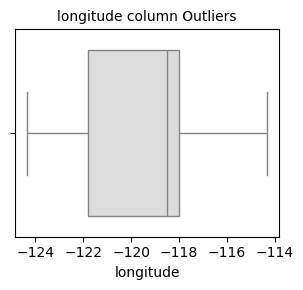

#==================================================#
latitude Column Has 0
#==================================================#


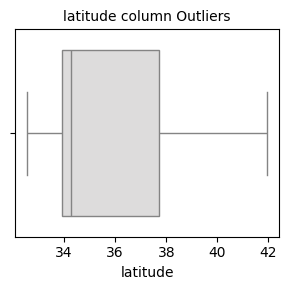

#==================================================#
housing_median_age Column Has 0
#==================================================#


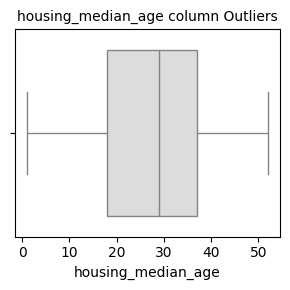

#==================================================#
total_rooms Column Has 1287
#==================================================#


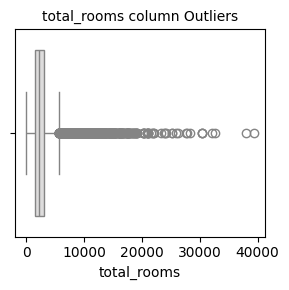

#==================================================#
total_bedrooms Column Has 1306
#==================================================#


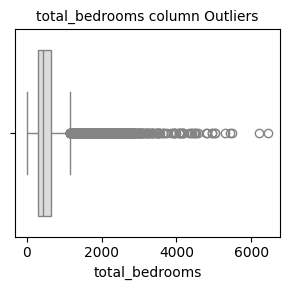

#==================================================#
population Column Has 1196
#==================================================#


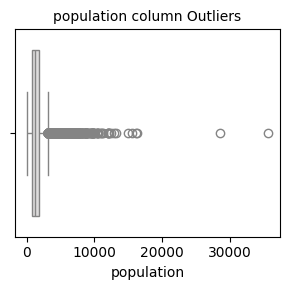

#==================================================#
households Column Has 1220
#==================================================#


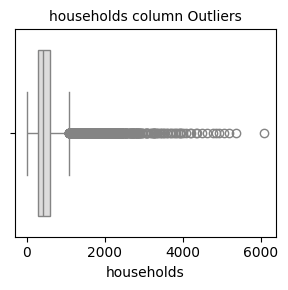

#==================================================#
median_income Column Has 681
#==================================================#


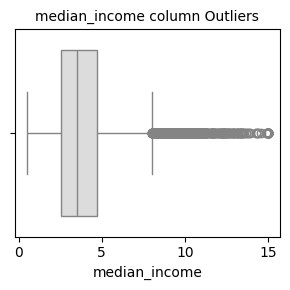

#==================================================#
median_house_value Column Has 1071
#==================================================#


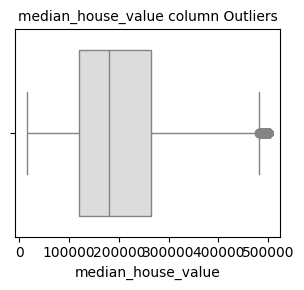

#==================================================#
rooms_per_bedrooms Column Has 329
#==================================================#


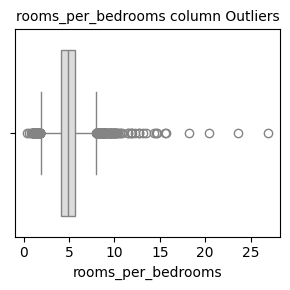

#==================================================#
rooms_per_households Column Has 511
#==================================================#


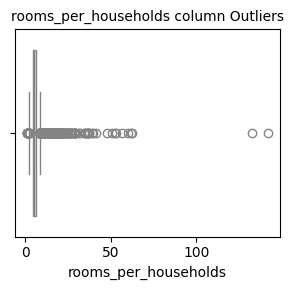

#==================================================#
income_per_age Column Has 1665
#==================================================#


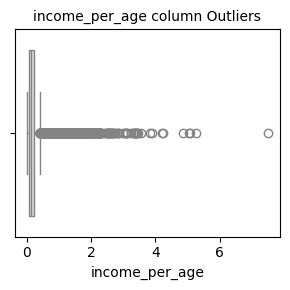

#==================================================#
lat_lon_cluster Column Has 0
#==================================================#


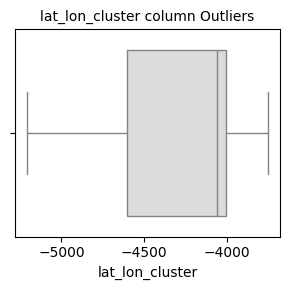

#==================================================#
dist_to_sf Column Has 0
#==================================================#


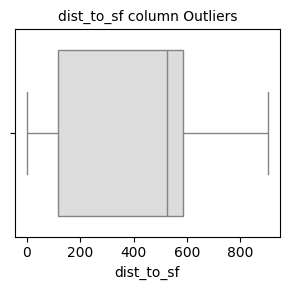

#==================================================#
dist_to_la Column Has 0
#==================================================#


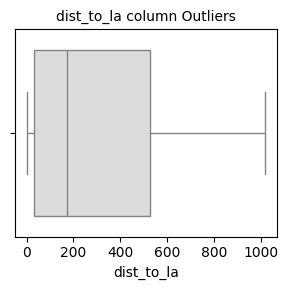

#============================================================#
Total Dataset Percentage Outliers Is: 20.75%
#============================================================#
Total Unique Outliers Present In Dataset: 4283
#============================================================#
✅ Outliers Detection Complete!


In [6]:
#================================================================================================#
# Outliers Detection
#================================================================================================#
outlier_data = house_df.copy()
outlier_box = set()
numeric_columns = outlier_data.select_dtypes(include = ['number']).columns
for num_col in numeric_columns:
    Q1 = outlier_data[num_col].quantile(0.25)
    Q3 = outlier_data[num_col].quantile(0.75)
    IQR = Q3 - Q1
    Lower_round = Q1 - 1.5 * IQR
    Upper_round = Q3 + 1.5 * IQR
    outliers = outlier_data[(outlier_data[num_col] < Lower_round) | (outlier_data[num_col] > Upper_round)]
    outlier_box.update(outliers.index)
    print("#" + "=" * 50 + "#")
    print(f"{num_col} Column Has {len(outliers)}")
    print("#" + "=" * 50 + "#")
    plt.figure(figsize = (3,3))
    plt.title(f"{num_col} column Outliers",fontsize = 10)
    sns.boxplot(x = outlier_data[num_col],palette = 'coolwarm')
    plt.xlabel(f"{num_col}")
    plt.tight_layout()
    plt.show()
    plt.close()
total_per = (len(outlier_box) / len(outlier_data)) * 100
print("#" + "=" * 60 + "#")
print(f"Total Dataset Percentage Outliers Is: {total_per:.2f}%")
print("#" + "=" * 60 + "#")
print(f"Total Unique Outliers Present In Dataset: {len(outlier_box)}")
print("#" + "=" * 60 + "#")
print("✅ Outliers Detection Complete!")

In [7]:
#=====================================================================================================#
# Remove Outliers
#=====================================================================================================#
house_df = house_df.drop(index = list(outlier_box),errors = 'ignore').reset_index(drop = True)
house_df.shape

(16357, 16)

#==================================================#


ocean_proximity
<1h ocean     7174
inland        5232
near ocean    2111
near bay      1835
island           5
Name: count, dtype: int64

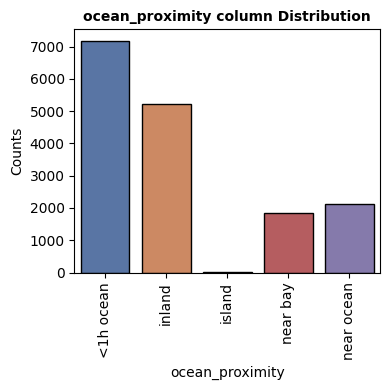

	#==================================================#


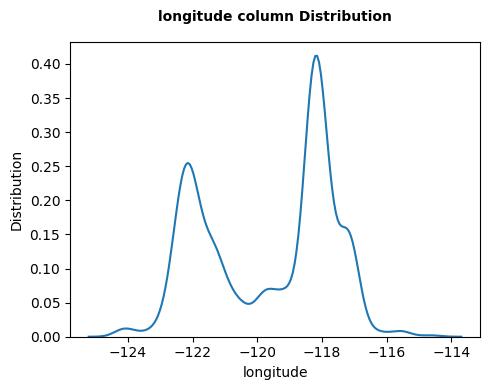

	#==================================================#


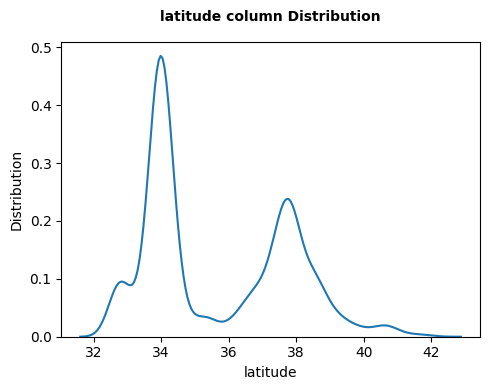

	#==================================================#


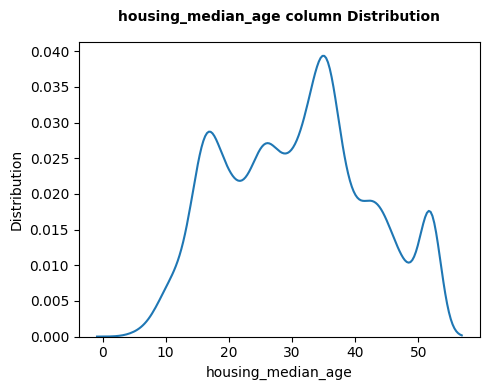

	#==================================================#


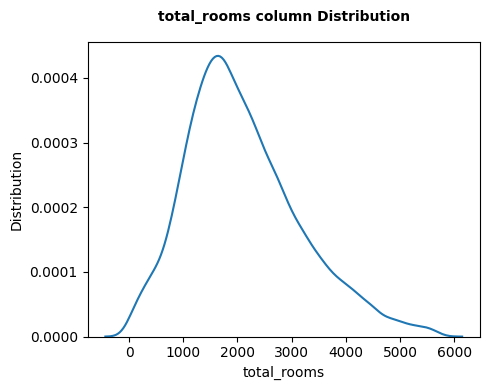

	#==================================================#


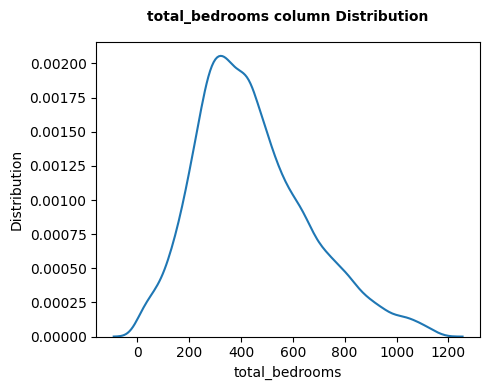

	#==================================================#


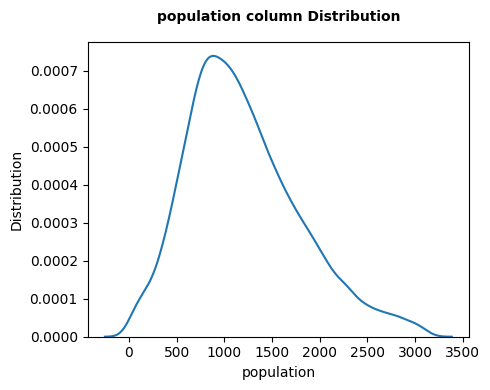

	#==================================================#


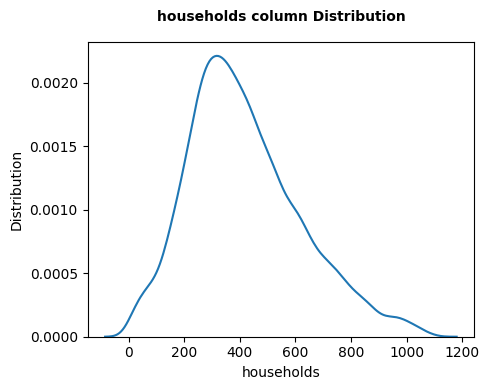

	#==================================================#


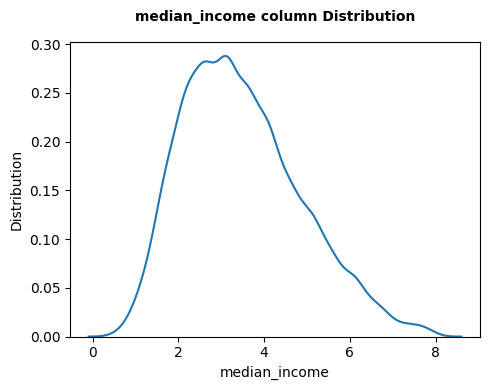

	#==================================================#


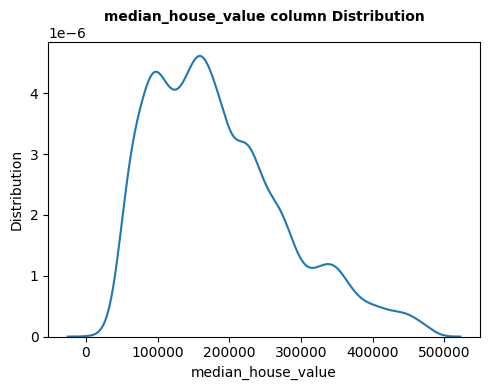

	#==================================================#


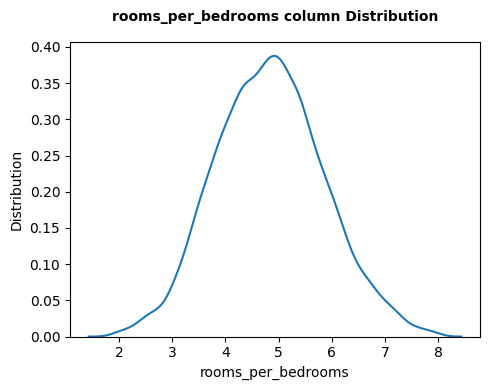

	#==================================================#


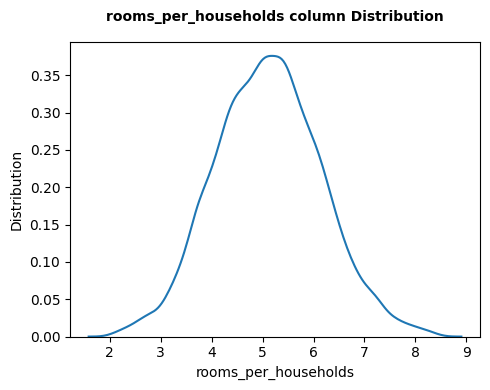

	#==================================================#


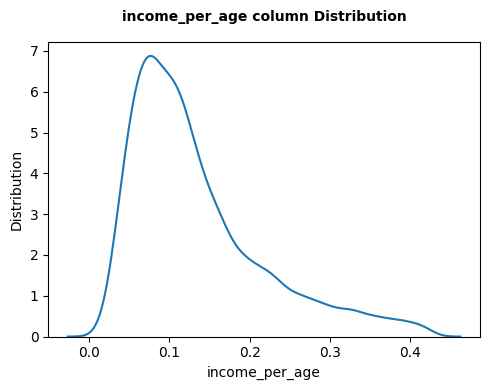

	#==================================================#


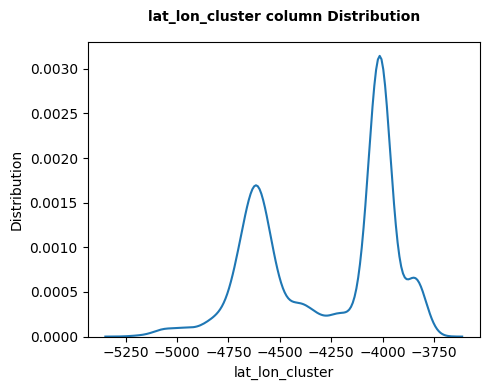

	#==================================================#


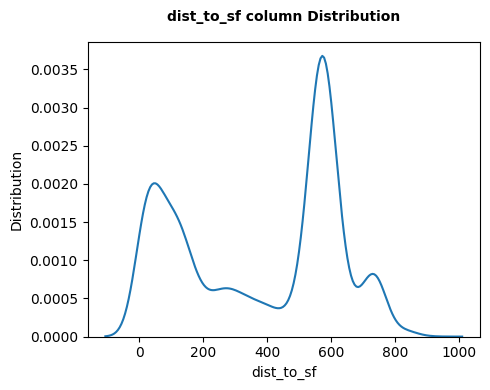

	#==================================================#


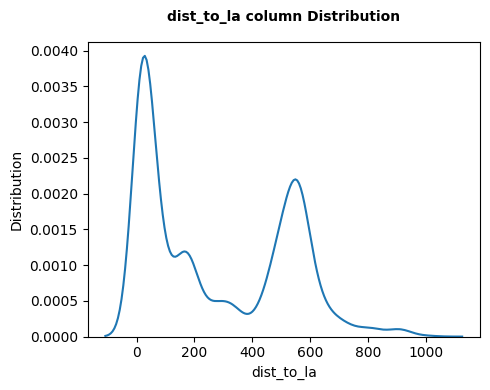

In [8]:
#=====================================================================================================#
# All Categorical Columns Distribution and There Types
#=====================================================================================================#
categorical_columns = house_df.select_dtypes(include = ['category']).columns
for cat_cols in categorical_columns:
    print("#" + "=" * 50 + "#")
    display(house_df[cat_cols].value_counts())
    plt.figure(figsize = (4,4))
    plt.title(f"{cat_cols} column Distribution",fontsize = 10,fontweight = 'bold')
    sns.countplot(data = house_df,x = cat_cols,palette = 'deep',edgecolor = 'black')
    plt.xlabel(f"{cat_cols}")
    plt.ylabel("Counts")
    plt.xticks(rotation = 'vertical')
    plt.tight_layout()
    plt.show()
#=====================================================================================================#
# All Numeric Columns Distribution
#=====================================================================================================#
numeric_columns = house_df.select_dtypes(include = ['number']).columns
for num_cols in numeric_columns:
    print("\t#" + "=" * 50 + "#")
    plt.figure(figsize = (5,4))
    plt.title(f"{num_cols} column Distribution",fontsize = 10,fontweight = 'bold',pad = 15)
    sns.kdeplot(data = house_df,x = num_cols)
    plt.xlabel(f"{num_cols}")
    plt.ylabel("Distribution")
    plt.tight_layout()
    plt.show()

#================================================== Average House Value Summary ==================================================#


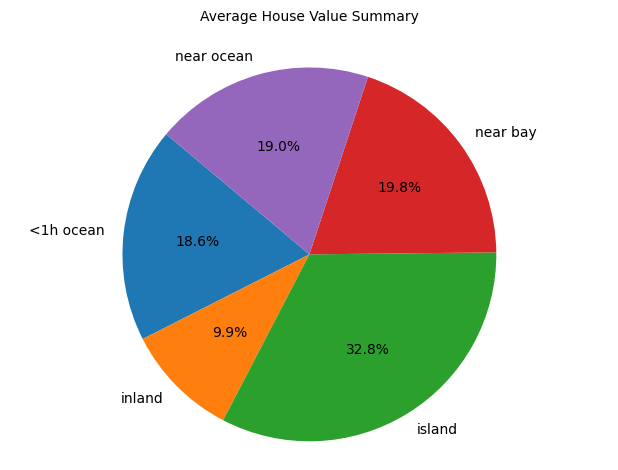

In [9]:
#=====================================================================================================#
# Average House Value of ocean proximity
#=====================================================================================================#
Average_house_value_summary = house_df.groupby('ocean_proximity')['median_house_value'].agg(
    Average_House_Value = 'mean'
)
print("#" + "=" * 50 + " Average House Value Summary " + "=" * 50 + "#")
Average_house_value_summary['Average_House_Value'].plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=140,
    ylabel='' 
)
plt.title("Average House Value Summary", fontsize=10, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

#================================================== Minimum House Value Summary ==================================================#


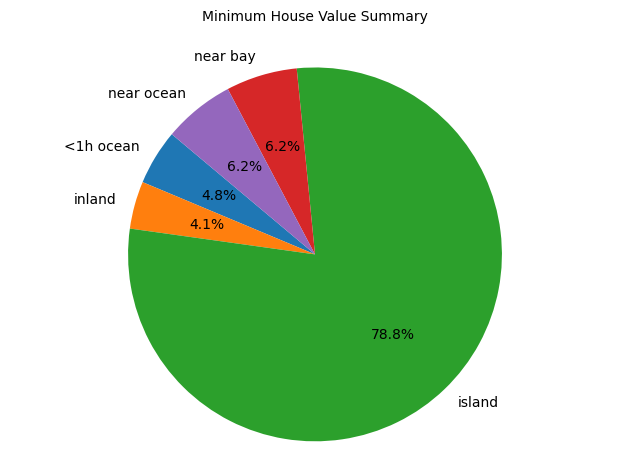

In [10]:
#=====================================================================================================#
# Minimum House Value of ocean proximity
#=====================================================================================================#
Minimum_house_value_summary = house_df.groupby('ocean_proximity')['median_house_value'].agg(
    Minimum_House_Value = 'min'
)
print("#" + "=" * 50 + " Minimum House Value Summary " + "=" * 50 + "#")
Minimum_house_value_summary['Minimum_House_Value'].plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=140,
    ylabel='' 
)
plt.title("Minimum House Value Summary", fontsize=10, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

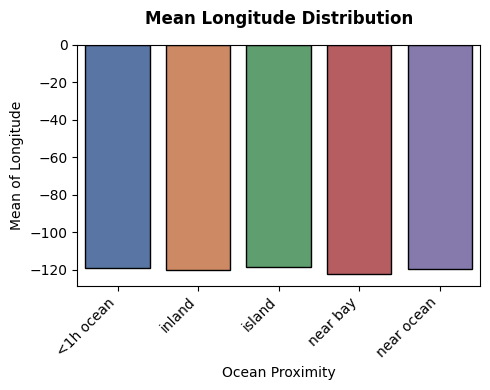

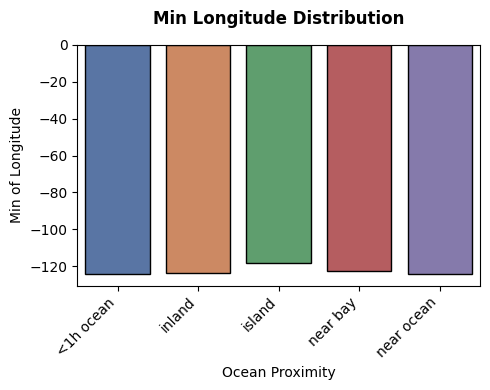

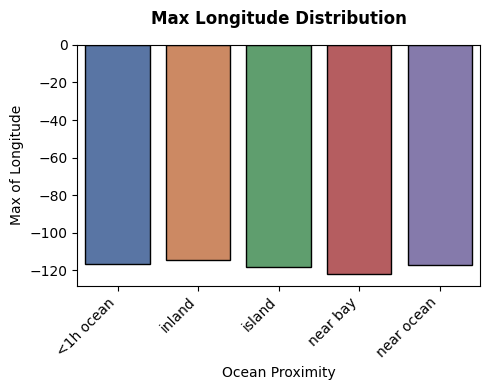

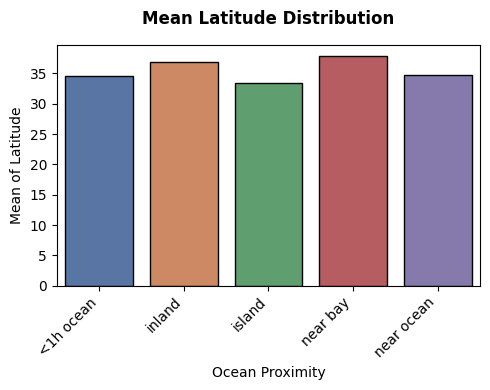

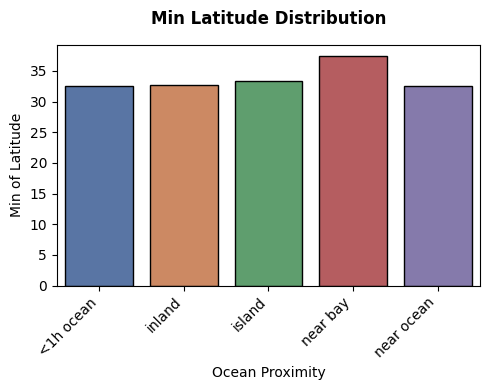

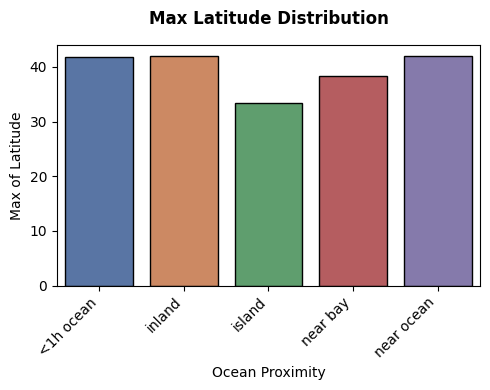

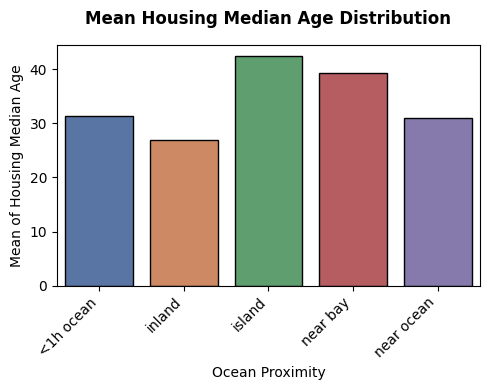

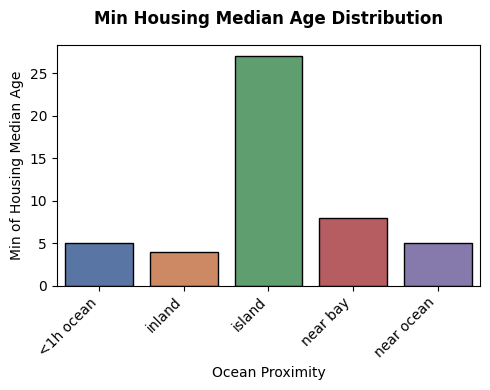

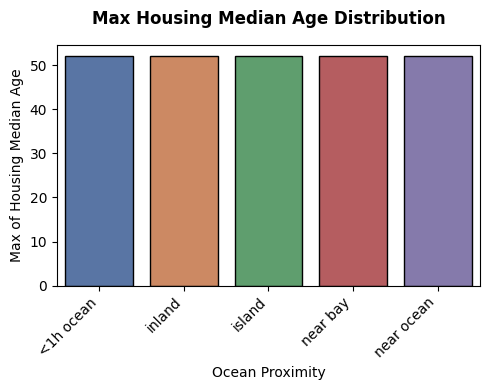

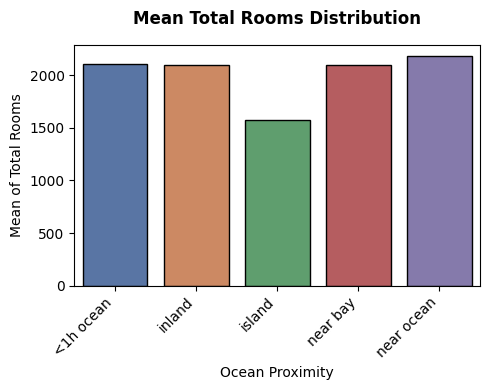

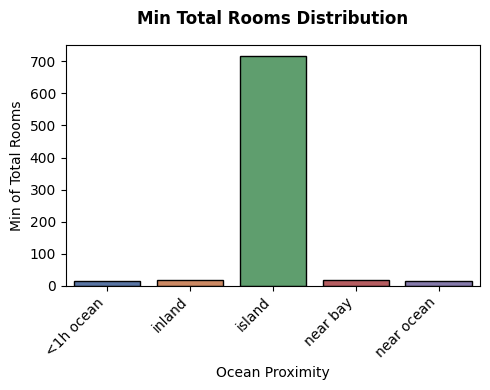

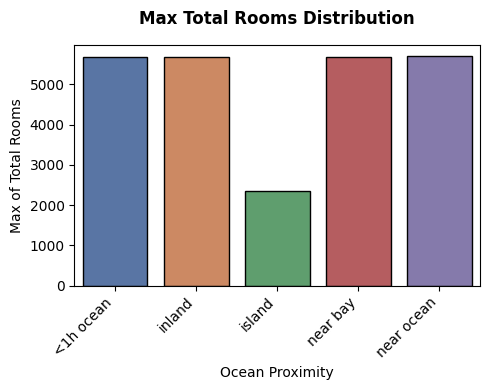

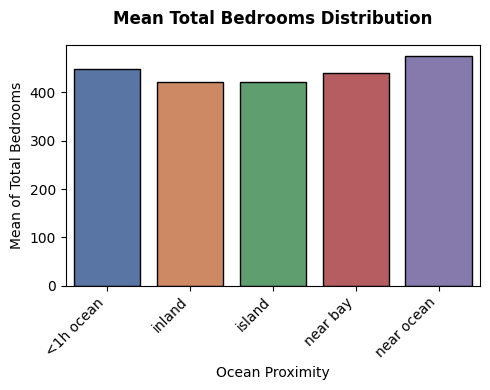

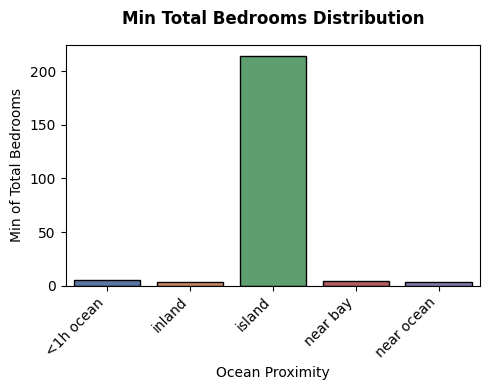

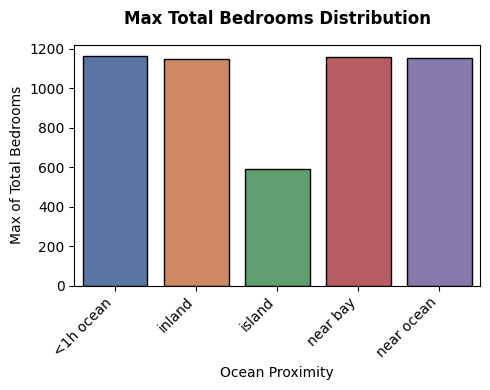

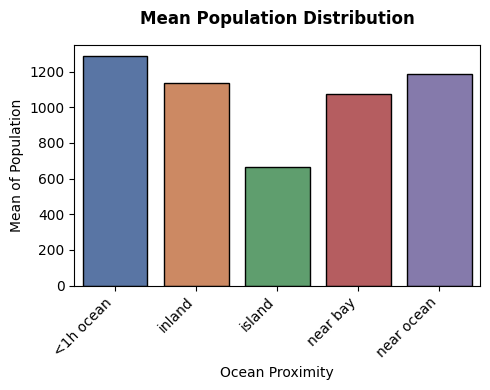

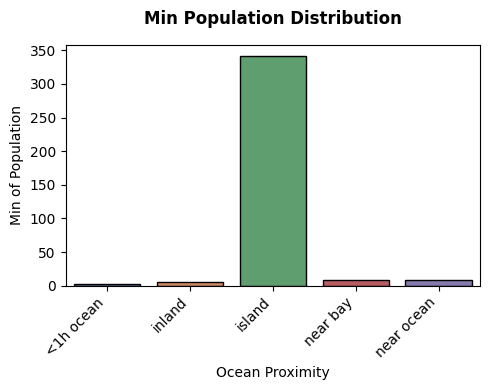

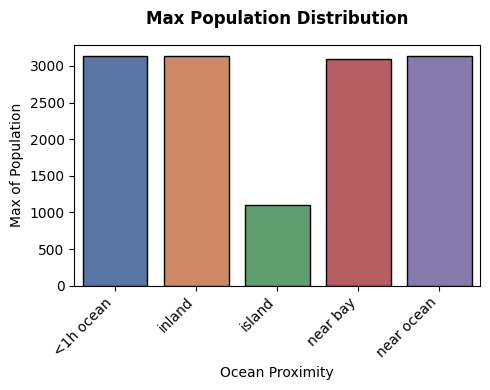

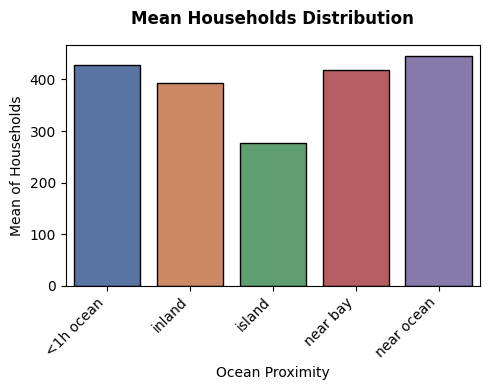

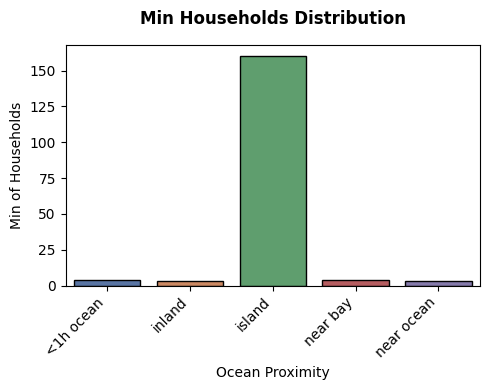

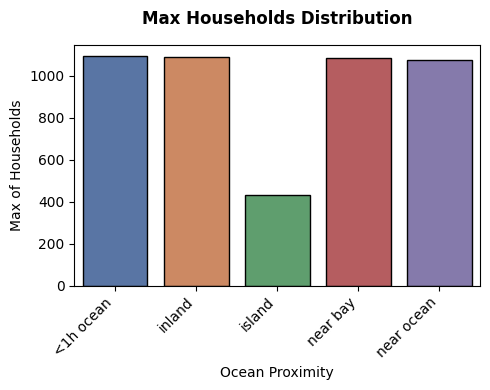

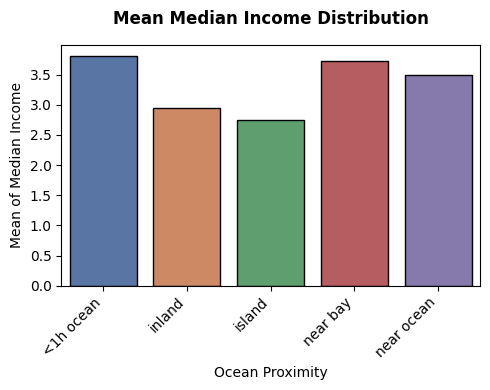

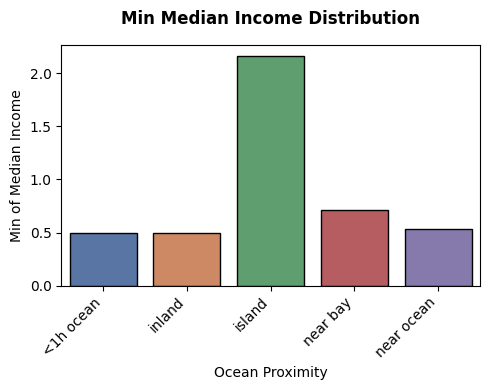

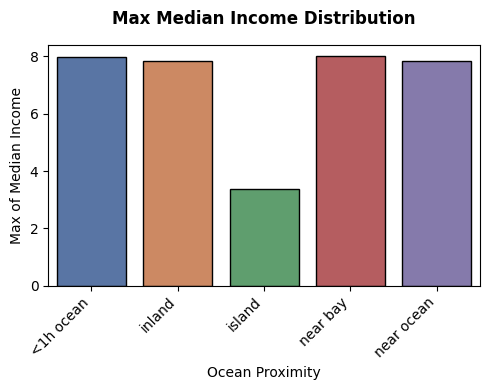

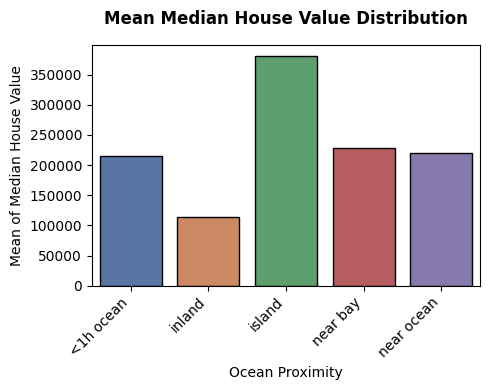

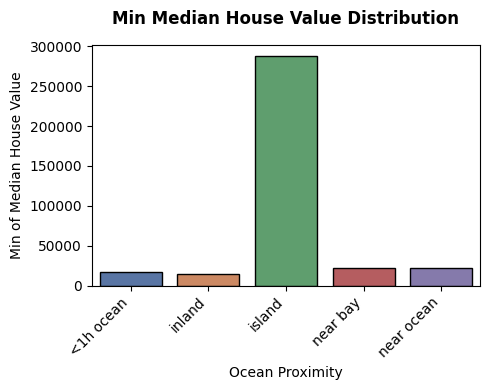

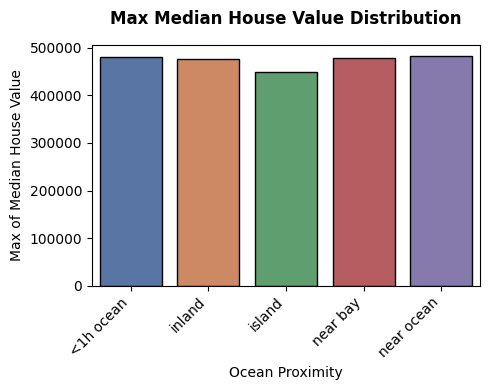

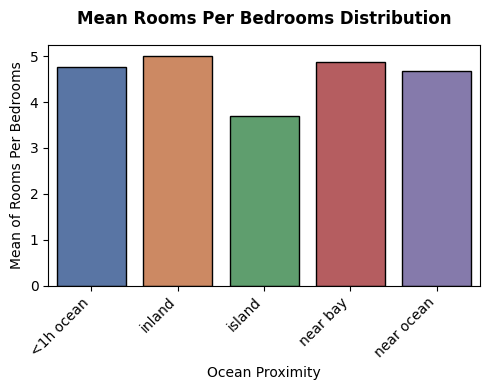

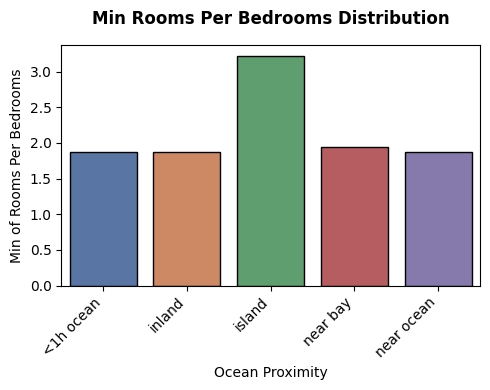

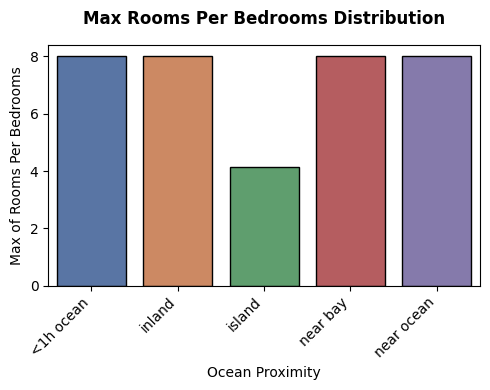

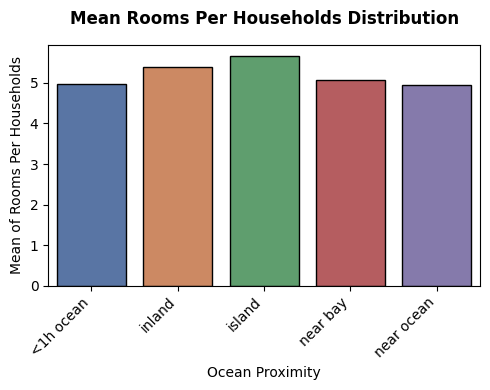

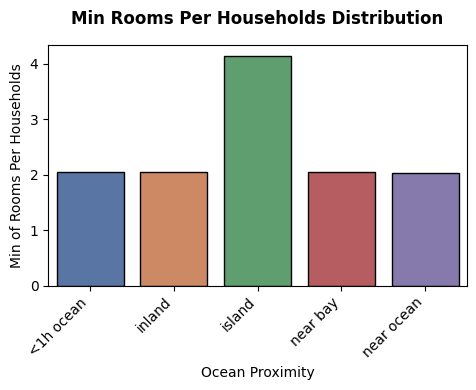

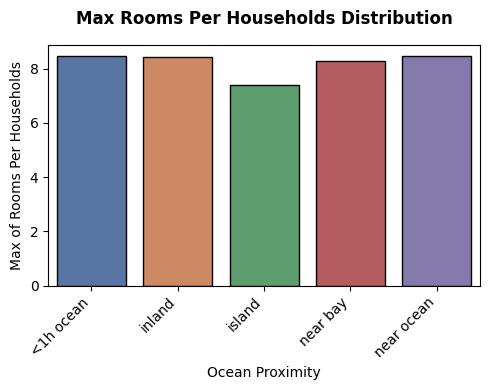

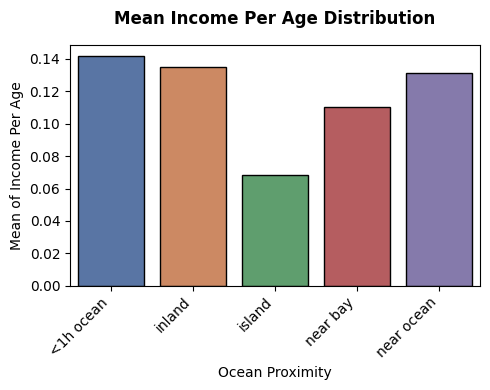

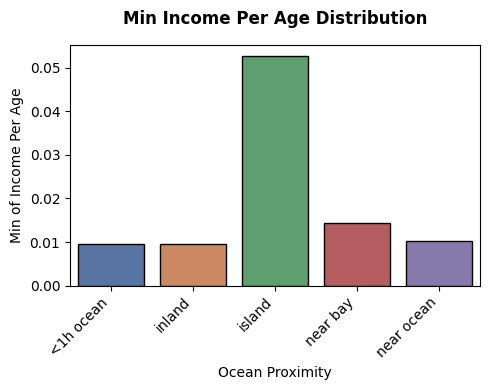

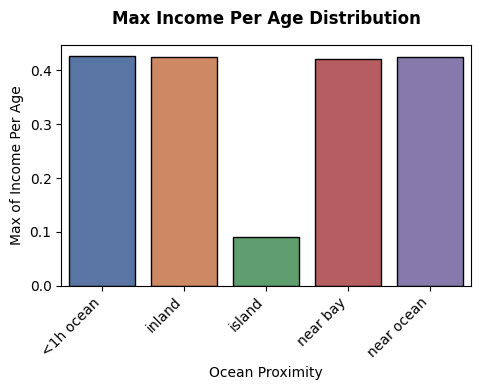

In [11]:
#======================================================================================================# 
# Distribution of All Columns From ocean_proximity 
#======================================================================================================# 
aggfunc = ['mean', 'min', 'max']
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 
           'population', 'households', 'median_income', 'median_house_value', 
           'rooms_per_bedrooms', 'rooms_per_households', 'income_per_age']
for col in columns:
    for agg in aggfunc:
        plt.figure(figsize=(5, 4))
        title_col = col.replace('_', ' ').title()
        plt.title(f"{agg.capitalize()} {title_col} Distribution", fontsize=12, fontweight='bold', pad=15)
        sns.barplot(
            data=house_df, 
            x='ocean_proximity', 
            y=col,
            estimator=agg, 
            errorbar=None, 
            edgecolor='black', 
            palette='deep'
        )
        plt.xlabel('Ocean Proximity')
        plt.ylabel(f'{agg.capitalize()} of {title_col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        plt.close()

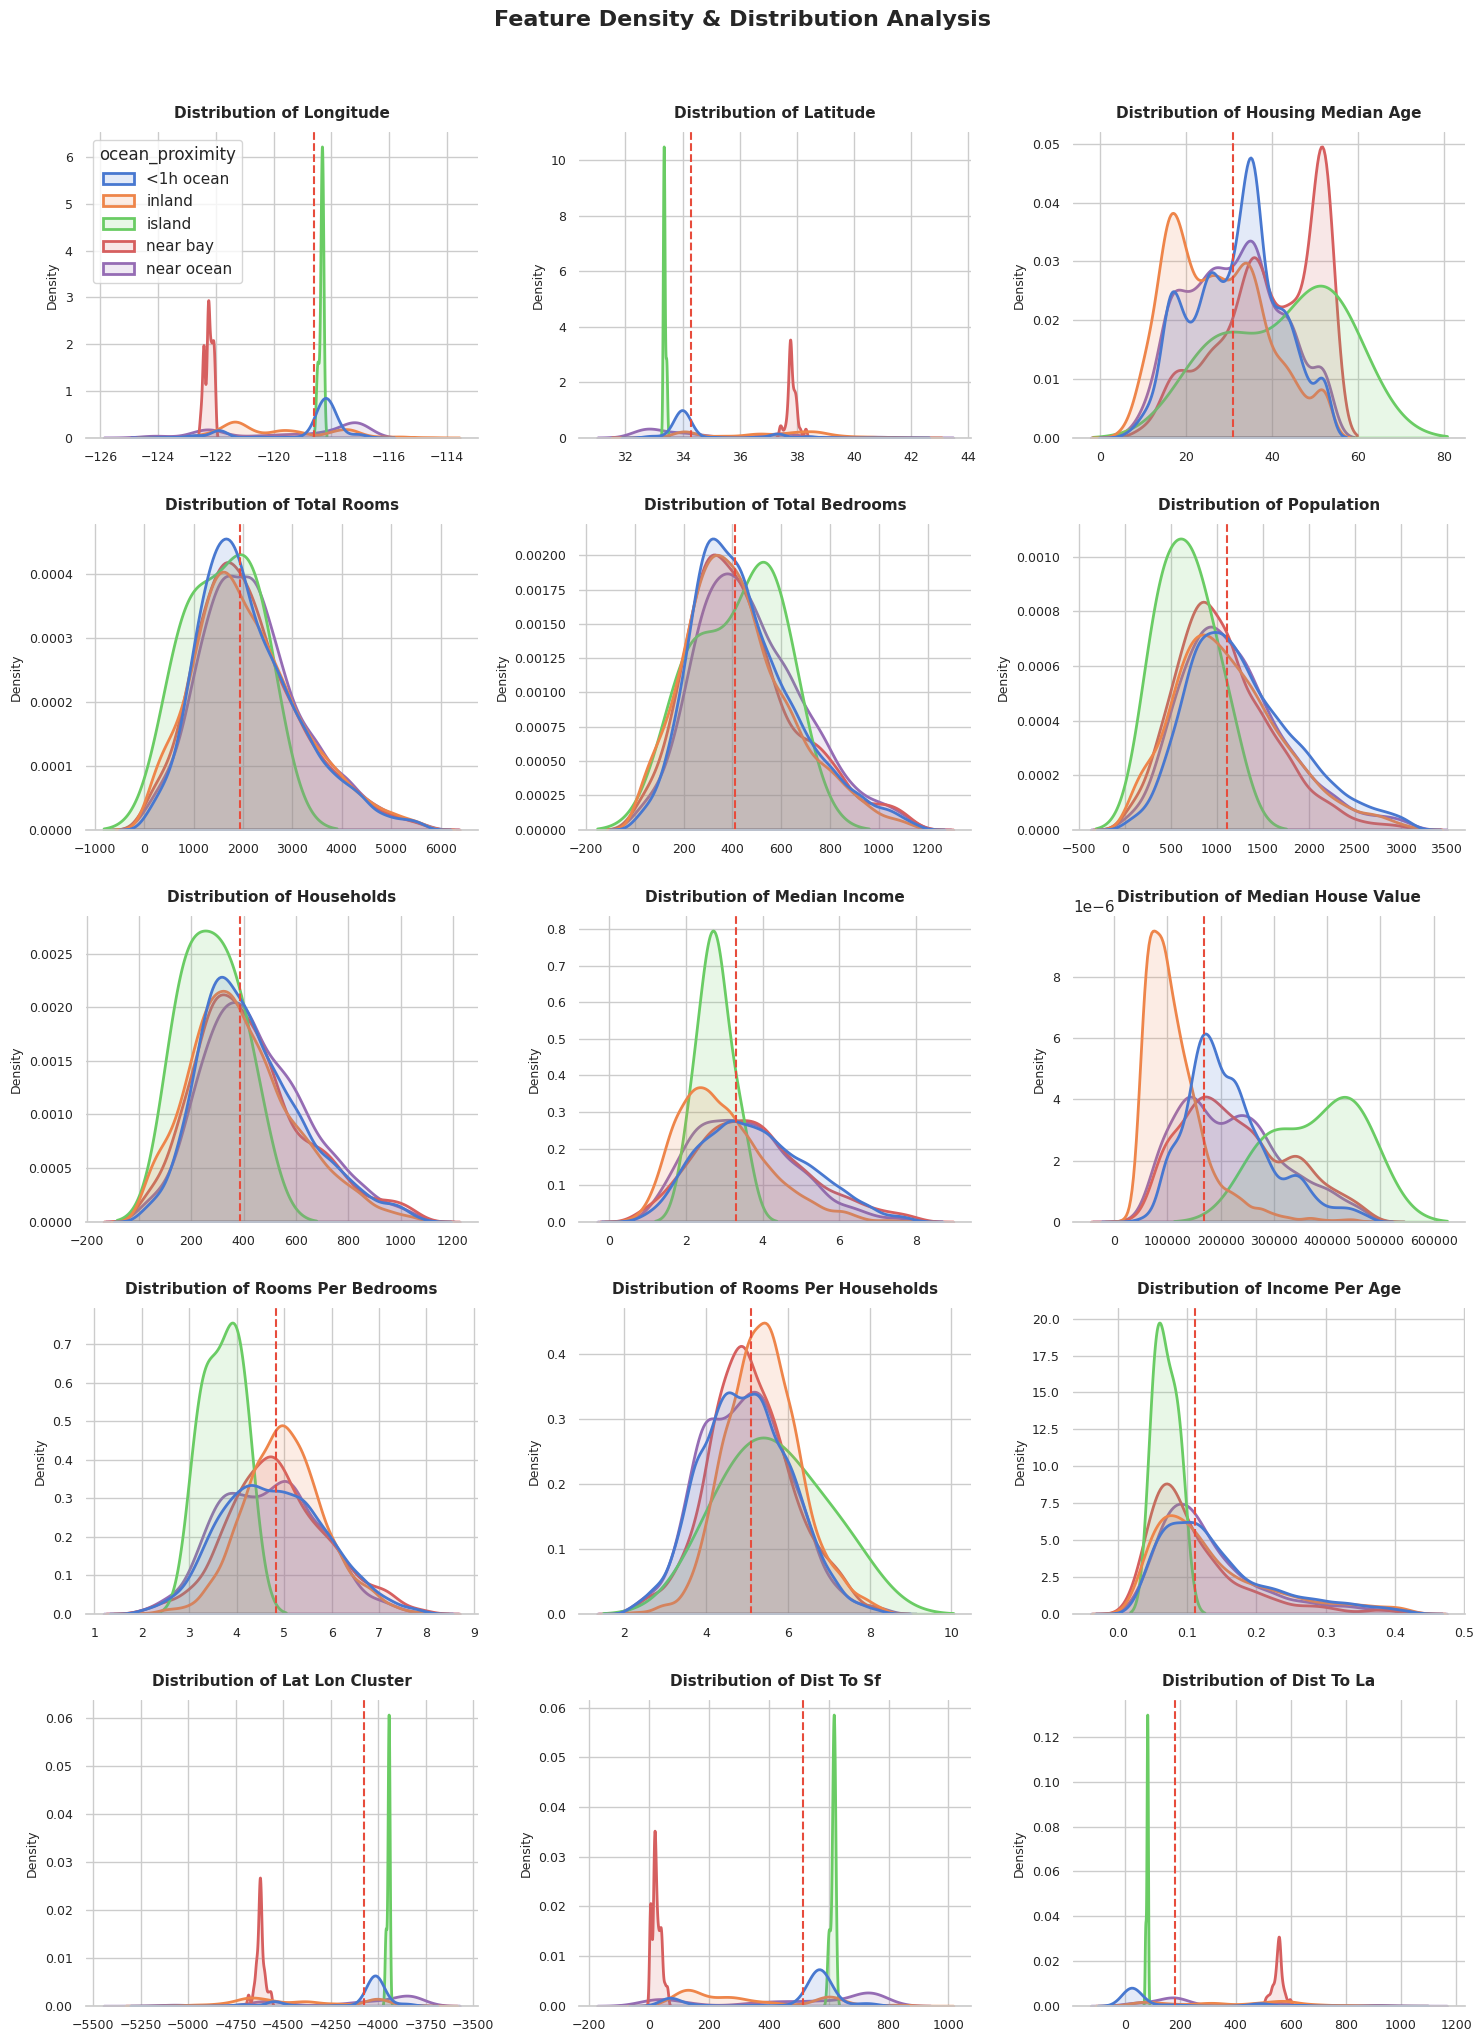

In [12]:
#======================================================================================================# 
# Distribution of All Numeric Columns
#======================================================================================================# 
sns.set_theme(style="whitegrid", palette="muted")
numeric_cols = house_df.select_dtypes(include=[np.number]).columns.tolist()
num_vars = len(numeric_cols)

n_cols = 3
n_rows = (num_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=False
)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    sns.kdeplot(
        data=house_df,
        x=col,
        hue="ocean_proximity",
        fill=True,
        alpha=0.15,
        linewidth=2,
        common_norm=False,
        ax=ax,
        legend=True if i == 0 else False,
    )

    median_val = house_df[col].median()
    ax.axvline(
        median_val,
        color="#e74c3c",
        linestyle="--",
        linewidth=1.5,
        label=f"Global Med: {median_val:.1f}",
    )

    ax.set_title(
        f"Distribution of {col.replace('_', ' ').title()}",
        fontsize=11,
        fontweight="bold",
        pad=10,
    )
    ax.set_xlabel("")
    ax.set_ylabel("Density", fontsize=9)
    ax.tick_params(labelsize=9)
    sns.despine(ax=ax, left=True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Feature Density & Distribution Analysis",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()
plt.close()


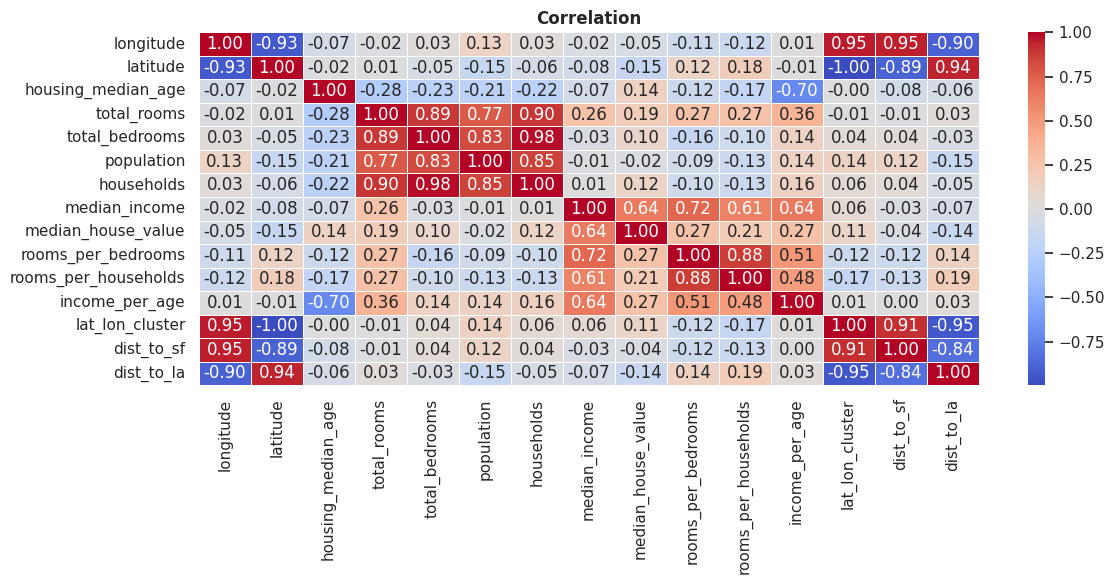

In [40]:
#======================================================================================================# 
# Check The Correlation
#======================================================================================================# 
num_columns = house_df.select_dtypes(include = ['number'])
plt.figure(figsize = (12,6))
plt.title("Correlation",fontsize = 12,fontweight = 'bold')
sns.heatmap(data = num_columns.corr(),annot = True,cmap = 'coolwarm',linewidths = 0.5,fmt = '.2f')
plt.tight_layout()
plt.show()

In [14]:
#======================================================================================================# 
# EDA Report 
#======================================================================================================# 
report = ProfileReport(house_df,explorative = True)
report.to_file(output_file = 'House_price_prediction_eda_report.html')
print("✅ Dataset EDA Complete!")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:00<00:00, 52.56it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Dataset EDA Complete!


# **Model Building**

In [15]:
#======================================================================================================# 
# Extract The Numeric and Categorical Features
#======================================================================================================# 
categorical_features = ['ocean_proximity']
numeric_transform_features = [
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income',
    'rooms_per_bedrooms',
    'rooms_per_households',
    'income_per_age'
]
numeric_features = ['longitude', 'latitude','dist_to_sf','dist_to_la','lat_lon_cluster']

X = house_df[categorical_features + numeric_transform_features + numeric_features]
target = house_df['median_house_value']
y = np.log1p(target)

In [16]:
#======================================================================================================# 
# Split The Data Into 2 Part Training and Testing 
#======================================================================================================#
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [17]:
#======================================================================================================# 
# Create A Object of ColumnTransformer
#======================================================================================================#
preprocessing_data = ColumnTransformer(transformers=[
    ('Numeric Features Transformer',PowerTransformer(method = 'yeo-johnson'),numeric_transform_features),
    ('Numeric Features Scaler',StandardScaler(),numeric_features),
    ('Categorical Features Encoder',OneHotEncoder(handle_unknown = 'ignore',drop = 'first',sparse_output = False),categorical_features)
])

In [18]:
#======================================================================================================# 
# Try Multiple Models
#======================================================================================================#
models = {
    ("LinearRegression",LinearRegression(
        n_jobs = -1
    )),
    ('Ridge',Ridge(
        alpha = 0.001,
        max_iter = 1000,
        solver = 'saga',
        random_state = 42
    )),
    ('RandomForestRegressor',RandomForestRegressor(
        n_estimators = 350,
        max_depth = 15,
        min_samples_split = 2,
        min_samples_leaf = 4,
        max_features = 'log2',
        random_state = 42,
        n_jobs = -1
    )),
    ('GradientBoostingRegressor',GradientBoostingRegressor(
        n_estimators = 400,
        max_depth = 15,
        min_samples_split = 3,
        min_samples_leaf = 4,
        max_features = 'log2',
        random_state = 42
    )),
    ('XGBRegressor',XGBRegressor(
        n_estimators = 350,
        max_depth = 15,
        random_state = 42
    )),
    ('LGBMRegressor',LGBMRegressor(
        n_estimators = 400,
        max_depth = 10,
        n_jobs = -1,
        random_state = 42,
        verbose = -1
    ))
}

In [19]:
#======================================================================================================# 
# Create A Object of Pipeline
#======================================================================================================#
for name, model in models:
    pipeline = Pipeline(steps=[
        ('Preprocessing Data', preprocessing_data),
        ('Feature Selection', SelectKBest(score_func=f_regression, k='all')),
        (name, model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred_log = pipeline.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test)  
    print("#" + "=" * 20 + f" {name} " + "=" * 20 + "#")
    print(f"MAE: {mean_absolute_error(y_test_original, y_pred)}")
    print(f"MSE: {mean_squared_error(y_test_original, y_pred)}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test_original, y_pred))}")
    print(f"R2: {r2_score(y_test_original, y_pred)}")

#==================== Ridge ====================#
MAE: 37824.2562918216
MSE: 2812957793.521539
RMSE: 53037.32453208343
R2: 0.6611143448587742
#==================== XGBRegressor ====================#
MAE: 27061.995758280485
MSE: 1662282403.6138787
RMSE: 40771.09765034391
R2: 0.7997397391899022
#==================== GradientBoostingRegressor ====================#
MAE: 24260.853774697625
MSE: 1393974594.2367876
RMSE: 37335.96917500318
R2: 0.8320636041158785
#==================== LinearRegression ====================#
MAE: 37635.79226770584
MSE: 2799587837.5319176
RMSE: 52911.13150870918
R2: 0.6627250644739734
#==================== LGBMRegressor ====================#
MAE: 24481.005954411645
MSE: 1364146104.8264384
RMSE: 36934.34857725852
R2: 0.8356571337447196
#==================== RandomForestRegressor ====================#
MAE: 26128.693099929635
MSE: 1568089013.678095
RMSE: 39599.10369791336
R2: 0.8110875058474315


# **Hyper Parameter Tuning**

In [22]:
pipeline_lgbm = Pipeline(steps=[
    ('preprocessing', preprocessing_data),
    ('lgbm', LGBMRegressor(random_state=42, verbose=-1))
])

param_dist = {
    'lgbm__n_estimators':       [200, 300, 400, 500, 550],
    'lgbm__max_depth':          [4, 5, 7, 10, 15, 20],
    'lgbm__learning_rate':      [0.001, 0.01, 0.05, 0.1],
    'lgbm__min_child_samples':  [10, 15, 20, 25, 30],
    'lgbm__num_leaves':         [15, 31, 50, 63],  
    'lgbm__boosting_type':      ['gbdt'],
    'lgbm__objective':          ['regression', 'regression_l1', 'huber'],
}

random_search = RandomizedSearchCV(
    estimator=pipeline_lgbm,
    param_distributions=param_dist,
    cv=5,
    n_iter=35,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    scoring='r2',
    return_train_score=True
)
random_search.fit(X_train, y_train)
print(f"Best Parameters : {random_search.best_params_}")
print(f"Best CV R²      : {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_
y_pred_lgbm = best_model.predict(X_test)

print(f"MAE  : {mean_absolute_error(y_test, y_pred_lgbm):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lgbm)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_lgbm):.4f}")

Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best Parameters : {'lgbm__objective': 'regression', 'lgbm__num_leaves': 50, 'lgbm__n_estimators': 550, 'lgbm__min_child_samples': 25, 'lgbm__max_depth': 20, 'lgbm__learning_rate': 0.05, 'lgbm__boosting_type': 'gbdt'}
Best CV R²      : 0.8419
MAE  : 0.1380
RMSE : 0.1982
R²   : 0.8556


In [35]:
#======================================================================================================# 
# Cross Validation
#======================================================================================================#
cv = KFold(shuffle = True,n_splits = 5,random_state = 42)
scores = cross_val_score(best_model,X,y,cv = cv,scoring = 'r2',n_jobs = -1)
print(scores)
print(scores.mean())
print(scores.std())

[0.85562129 0.85238566 0.85378318 0.84158174 0.84116819]
0.8489080116728648
0.006237122827860674


In [34]:
from sklearn.model_selection import KFold, cross_validate
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error'
}
results = cross_validate(best_model, X, y, cv=cv, scoring=scoring_metrics, n_jobs=-1)

print("--- CROSS VALIDATION METRICS ---")
print(f"R² Score : {np.mean(results['test_r2']):.4f} (± {np.std(results['test_r2']):.4f})")
print(f"MAE      : {-np.mean(results['test_mae']):.4f} (± {np.std(results['test_mae']):.4f})")
print(f"MSE      : {-np.mean(results['test_mse']):.4f} (± {np.std(results['test_mse']):.4f})")
print(f"RMSE     : {np.sqrt(-np.mean(results['test_mse'])):.4f}")


--- CROSS VALIDATION METRICS ---
R² Score : 0.8489 (± 0.0062)
MAE      : 0.1416 (± 0.0026)
MSE      : 0.0427 (± 0.0021)
RMSE     : 0.2066


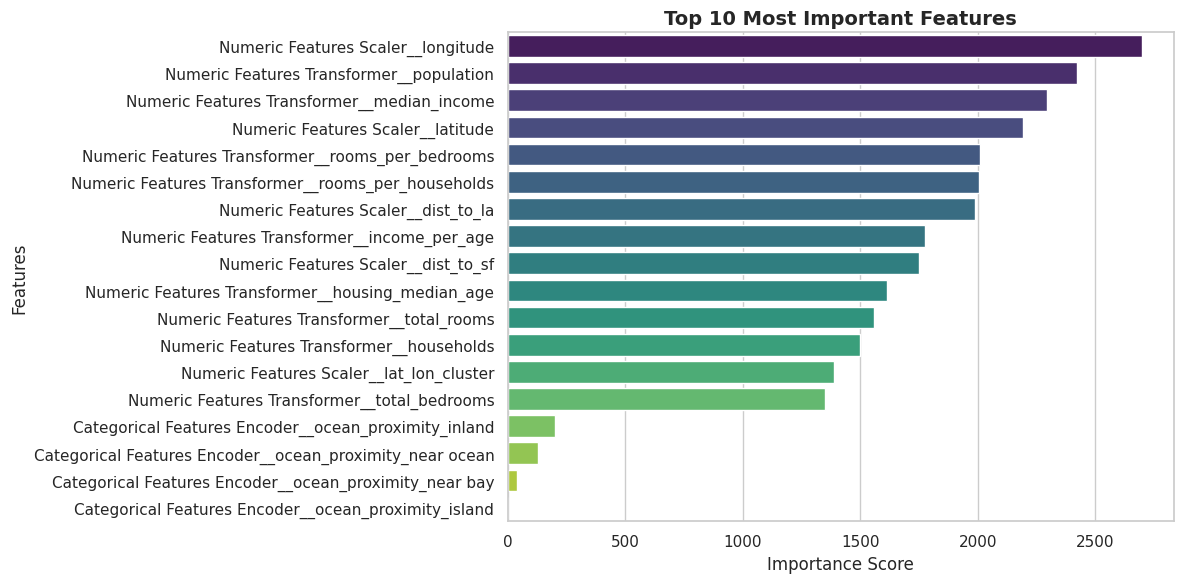

In [44]:
#======================================================================================================# 
# Features Important
#======================================================================================================#
if hasattr(best_model, 'named_steps'):
    lgbm_model = best_model.named_steps['lgbm']
    if hasattr(best_model, 'get_feature_names_out'):
        try:
            feature_names = best_model.get_feature_names_out()
        except:
            first_step = list(best_model.named_steps.keys())[0]
            feature_names = best_model.named_steps[first_step].get_feature_names_out()
    else:
        feature_names = lgbm_model.feature_name_
else:
    lgbm_model = best_model
    feature_names = lgbm_model.feature_name_ if hasattr(lgbm_model, 'feature_name_') else pd.DataFrame(X).columns

importances = lgbm_model.feature_importances_

if len(feature_names) != len(importances):
    print(f"Length mismatch: Features ({len(feature_names)}) vs Importances ({len(importances)})")
    feature_names = [f"Feature_{i}" for i in range(len(importances))]

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)
top_10 = fi_df

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_10, 
    palette='viridis', 
    hue='Feature', 
    legend=False
)
plt.title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()


In [45]:
#======================================================================================================# 
# Save The Model
#======================================================================================================#
joblib.dump(best_model,'best_model_House_price.pkl')
print("✅ Model Saved Complete!")

✅ Model Saved Complete!
